# Analysis of sampling constraints given geometry and turbulence conditions (Listing 9.6 J. Schmidt)

[31.3113199  18.42739218]
[0.12664241 0.43648967]
[0.12664241 0.43648967]


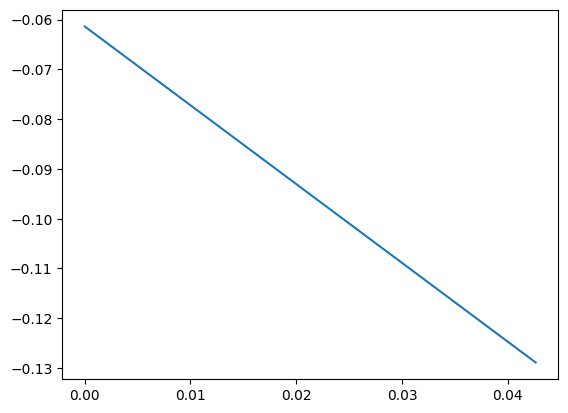

In [8]:
import numpy as np
import matplotlib.pyplot as plt

%run demo_pt_source_atmos_setup.ipynb

#### analysis_pt_source_atmos_samp.ipynb

c = 2
D1p = D1 + c*wvl*Dz/r0sw
D2p = D2 + c*wvl*Dz/r0sw

delta1 = np.linspace(0, 1.1*wvl*Dz/D2p, 100, endpoint=True)
deltan = np.linspace(0, 1.1*wvl*Dz/D1p, 100, endpoint=True)

# Constraint 1
deltan_max = -D2p/D1p*delta1 - wvl*Dz/D1p

# Constraint 3
d2min3 = (1+Dz/R)*delta1 - wvl*Dz/D1p
d2max3 = (1+Dz/R)*delta1 + wvl*Dz/D1p
delta1,deltan = np.meshgrid(delta1,deltan)

# Constraint 2
with np.errstate(divide='ignore'):
    N2 = (wvl*Dz + D1p*deltan + D2p*delta1) / (2*delta1*deltan)

# Constraint 4
d1 = 10e-3
d2 = 10e-3
N = 512
d1*d2*N/wvl
zmax = np.min(np.array([d1,d2])**2 * N/wvl)
nmin = np.ceil(Dz/zmax) + 1

# Plot figs
fig,ax = plt.subplots()
ax.plot(delta1[0,:],deltan_max)

plt.show()